In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Loading Data
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()


In [6]:
import os
os.getcwd()

'c:\\Users\\mahes'

In [8]:
# Shape of Data how many rows and columns
print(df.shape)

(9994, 21)


In [ ]:
# Column names & data types
df.info()

In [ ]:
#Missing Values
df.isnull().sum()

In [ ]:
# Basic Stats
df.describe()

In [61]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [62]:
# Extracting Year and month for Trend Analysis

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')

# Calculate days to ship

df['Days to ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Calculate profit margin %%

df['Profit Margin %']=(df['Profit']/df['Sales'])*100

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Days to ship,Profit Margin %
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct,7,11.25


In [64]:
# Question1: Which categories are most/least Profitable

category_perf =df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin %', 'mean'),
    Order_Count=('Order ID', 'count')
).round(2).sort_values('Total_Profit', ascending=False)

print(category_perf)

                 Total_Sales  Total_Profit  Avg_Margin  Order_Count
Category                                                           
Technology         836154.03     145454.95       15.61         1847
Office Supplies    719047.03     122490.80       13.80         6026
Furniture          741999.80      18451.27        3.88         2121


In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

#Sales by Category
axes[0].bar(category_perf.index, category_perf['Total_Sales'], color=['#2196F3','#4CAF50','#FF9800'])
axes[0].set_title('Total sales by Category')
axes[0].set_ylabel('Sales ($)')

#Profit by Category
axes[1].bar(category_perf.index, category_perf['Total_Profit'], color=['#2196F3','#4CAF50','#FF9800'])
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig('category_performance.png', dpi=150)
plt.show()

In [ ]:
# Which subcategory is the problem? 

subcat_perf = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Discount=('Discount','mean'),
    Avg_margin=('Profit Margin %','mean')
).round(2).sort_values('Total_Profit', ascending=True)

print(subcat_perf)

In [ ]:
bottom_subcat= subcat_perf.head(10).reset_index()

colors = ['#d32f2f' if x < 0 else '#FF9800' for x in bottom_subcat['Total_Profit']]

plt.figure(figsize=(12, 6))
plt.barh(bottom_subcat['Sub-Category'], bottom_subcat['Total_Profit'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Bottom 10 Sub-Categories by Profit (Loss-makers in Red)')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('subcategory_profit.png', dpi=150)
plt.show()

In [ ]:
# Is discounting the cause?

# Discount vs Profit relationship

discount_profit=df.groupby('Sub-Category').agg(
    Avg_Discount=('Discount','mean'),
    Total_Profit=('Profit','sum'),
    Avg_Margin=('Profit Margin %','mean')
).round(2).sort_values('Avg_Discount',ascending=False)

print(discount_profit)

In [ ]:
# Scatter plot - does higher discount = low profit margin?
plt.figure(figsize=(12,7))

scatter_data= df.groupby('Sub-Category').agg(
    Avg_Discount=('Discount','mean'),
    Avg_Margin=('Profit Margin %','mean'),
    Total_Sales=('Sales','sum')
).reset_index()
colors = ['#d32f2f' if x < 0 else '#2196F3' for x in scatter_data['Avg_Margin']]

plt.scatter(scatter_data['Avg_Discount'],
            scatter_data['Avg_Margin'],
            s=scatter_data['Total_Sales']/500,
            c=colors, alpha=0.7)
#Label each dot

for i, row in scatter_data.iterrows():
    plt.annotate(row['Sub-Category'],
                 (row['Avg_Discount'],row['Avg_Margin']),
                 textcoords="offset points", xytext=(5,5), fontsize=8)

plt.axhline(y=0,color='black', linewidth=0.8, linestyle='--')
plt.title('Discount vs Profit Margin by Sub-Category\n(Bubble size = Total Sales)')
plt.xlabel('Average Discount')
plt.ylabel('Average Profit Margin %')
plt.tight_layout()
plt.savefig('discount_vs_profit.png',dpi=150)
plt.show()


In [ ]:
# Regoinal Performance ?

region_perf=df.groupby('Region').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Margin=('Profit Margin %','mean'),
    Order_Count=('Order ID','count')
).round(2).sort_values('Total_Profit', ascending=False)

print(region_perf)

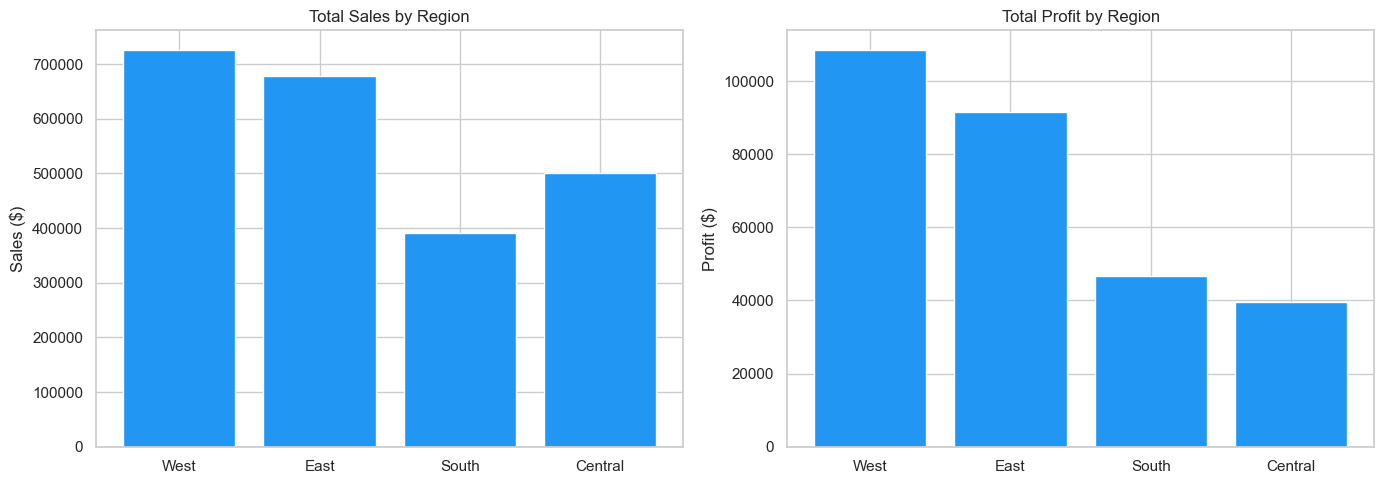

In [41]:
fig, axes= plt.subplots(1, 2, figsize=(14, 5))

# sales by region
axes[0].bar(region_perf.index, region_perf['Total_Sales'], color='#2196F3')
axes[0].set_title('Total Sales by Region')
axes[0].set_ylabel('Sales ($)')

# Profit by region
colors = ['#d32f2f' if x < 0 else '#4CAF50' for x in region_perf['Total_Profit']]
axes[1].bar(region_perf.index, region_perf['Total_Profit'], color='#2196F3')
axes[1].set_title('Total Profit by Region')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig('region_performace.png', dpi=150)
plt.show()


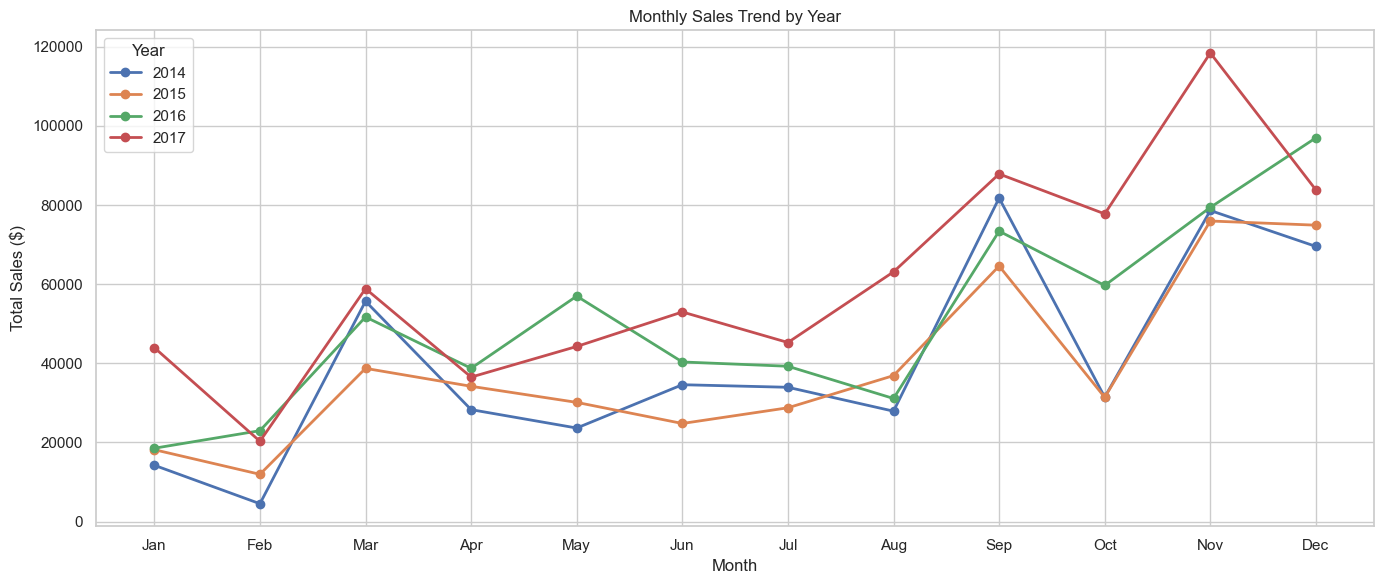

In [44]:
# Seasonal Trends?

monthly_sales=df.groupby(['Order Year', 'Order Month', 'Order Month Name']).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
).reset_index().sort_values(['Order Year', 'Order Month'])

# Plot each year as a line

plt.figure(figsize=(14,6))

for year in monthly_sales['Order Year'].unique():
    data = monthly_sales[monthly_sales['Order Year']==year]
    plt.plot(data['Order Month'], data['Total_Sales'],
             marker = 'o', label=str(year), linewidth=2)

plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('seasonal_trends.png', dpi=150)
plt.show()

In [43]:
# Top 10 customers by profit
top_customers =df.groupby('Customer Name').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Order_Count=('Order ID','nunique')
).round(2).sort_values('Total_Profit',ascending=False).head(10)

print(top_customers)

                      Total_Sales  Total_Profit  Order_Count
Customer Name                                               
Tamara Chand             19052.22       8981.32            5
Raymond Buch             15117.34       6976.10            6
Sanjit Chand             14142.33       5757.41            9
Hunter Lopez             12873.30       5622.43            6
Adrian Barton            14473.57       5444.81           10
Tom Ashbrook             14595.62       4703.79            4
Christopher Martinez      8954.02       3899.89            4
Keith Dawkins             8181.26       3038.63           12
Andy Reiter               6608.45       2884.62            6
Daniel Raglin             8350.87       2869.08            8


In [50]:
# Load into SQL

conn= sqlite3.connect(':memory:')
df.to_sql('superstore',conn, index=False, if_exists='replace')

print("All set! Data Loaded & SQL ready")

All set! Data Loaded & SQL ready


In [52]:
# Query 1: Category Profitability

query1 = """
SELECT
    Category,
    ROUND(SUM(Sales),2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit)*100.0/SUM(Sales), 2) AS Avg_Margin,
    COUNT(*) AS Order_Count
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC

"""
pd.read_sql(query1, conn)

,Category,Total_Sales,Total_Profit,Avg_Margin,Order_Count
0,Technology,836154.03,145454.95,17.40,1847
1,Office Supplies,719047.03,122490.80,17.04,6026
2,Furniture,741999.80,18451.27,2.49,2121


In [53]:
# Query2: Loss-Making Sub-Categories

query2="""
SELECT
    Category,"Sub-Category",
    ROUND(SUM(Sales),2) AS Total_Sales,
    ROUND(SUM(Profit),2) AS Total_Profit,
    ROUND(AVG(Discount),2) AS Avg_Discount
FROM superstore
GROUP BY Category, "Sub-Category"
Having Total_Profit < 0
ORDER BY Total_Profit ASC

"""
pd.read_sql(query2, conn)

,Category,Sub-Category,Total_Sales,Total_Profit,Avg_Discount
0,Furniture,Tables,206965.53,-17725.48,0.26
1,Furniture,Bookcases,114880.00,-3472.56,0.21
2,Office Supplies,Supplies,46673.54,-1189.10,0.08


In [ ]:
# Query3: Discount Impact (Window Function)

query3 = """
SELECT
    "Sub-Category",
    ROUND(AVG(Discount),2) AS Avg_Discount,
    ROUND(SUM(Profit),2) AS Total_Profit,
    ROUND(SUM(Profit)*100.0/SUM(Sales), 2) AS Avg_Margin,
    RANK() OVER (ORDER BY AVG(Discount) DESC) AS Discount_Rank
FROM superstore
GROUP BY "Sub-Category"
ORDER BY Avg_Discount DESC
"""
pd.read_sql(query3, conn)

In [55]:
# Quer4: Regional Performance

query4= """
SELECT
    Region,
    ROUND(SUM(Sales),2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit)*100.0/SUM(Sales), 2) AS Avg_Margin,
    COUNT(DISTINCT "Customer ID") AS Unique_Customers
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC
"""

pd.read_sql(query4, conn)

,Region,Total_Sales,Total_Profit,Avg_Margin,Unique_Customers
0,West,725457.82,108418.45,14.94,686
1,East,678781.24,91522.78,13.48,674
2,South,391721.91,46749.43,11.93,512
3,Central,501239.89,39706.36,7.92,629


In [57]:
# Query5: Top 10 Customers(CTE)

query5 = """
WITH customer_stats AS(
    SELECT
        "Customer Name",
        "Segment",
        "Region",
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit,
        COUNT(DISTINCT "Order ID") AS Total_Orders,
        ROUND(AVG(Discount),2) AS Avg_Discount
    FROM superstore
    GROUP BY "Customer Name", "Segment", "Region"
)
SELECT *,
    RANK() OVER (ORDER BY Total_Profit DESC) AS Profit_Rank
FROM customer_stats
ORDER BY Total_Profit DESC
LIMIT 10


"""
pd.read_sql(query5, conn)

,Customer Name,Segment,Region,Total_Sales,Total_Profit,Total_Orders,Avg_Discount,Profit_Rank
0,Tamara Chand,Corporate,Central,18437.14,8745.06,2,0.14,1
1,Raymond Buch,Consumer,West,14345.28,6807.09,2,0.03,2
2,Adrian Barton,Consumer,Central,12181.59,5362.61,5,0.25,3
3,Hunter Lopez,Consumer,East,10522.55,5045.86,2,0.00,4
4,Sanjit Chand,Consumer,Central,9900.19,4668.69,1,0.00,5
5,Tom Ashbrook,Home Office,East,13723.50,4599.21,2,0.04,6
6,Christopher Martinez,Consumer,South,6682.26,3197.46,2,0.00,7
7,Daniel Raglin,Home Office,East,6937.87,3050.33,2,0.00,8
8,Sanjit Engle,Consumer,South,8805.04,2825.29,1,0.00,9
9,Andy Reiter,Consumer,Central,5802.70,2602.09,1,0.00,10


In [65]:
# Export Cleaned dataframe for Power BI
df.to_csv('superstore_cleaned.csv', index=False)
print("File Saved")

File Saved


In [63]:
print(df['Order Month Name'].unique())

['Nov' 'Jun' 'Oct' 'Apr' 'Dec' 'May' 'Aug' 'Jul' 'Sep' 'Jan' 'Mar' 'Feb']
